In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
output_base = "."

In [3]:
output_file = os.path.join(output_base, "fluxes.h5")
with h5py.File(output_file, 'r') as f:
    e_loaded     = f["e"][:]
    dp_loaded    = f["dp"][:]
    EdotNorm_loaded   = f["EdotNorm"][:]   # (n_dp, n_e, N_psi)
    LdotNorm_loaded = f["LdotNorm"][:]

print(f"e:         {e_loaded.shape}  ->  {e_loaded}")
print(f"dp:        {dp_loaded.shape}")
print(f"magnitude: {EdotNorm_loaded.shape}  (n_dp, n_e, N_psi)")
print(f"phase:     {LdotNorm_loaded.shape}")

e:         (33,)  ->  [0.      0.03125 0.0625  0.09375 0.125   0.15625 0.1875  0.21875 0.25
 0.28125 0.3125  0.34375 0.375   0.40625 0.4375  0.46875 0.5     0.53125
 0.5625  0.59375 0.625   0.65625 0.6875  0.71875 0.75    0.78125 0.8125
 0.84375 0.875   0.90625 0.9375  0.96875 1.     ]
dp:        (65,)
magnitude: (65, 33)  (n_dp, n_e, N_psi)
phase:     (65, 33)


In [5]:
EdotNorm_loaded

array([[2589.94664314, 1291.27501211, 1121.82961413, ..., 6479.78086268,
        6592.33032731, 6572.00582878],
       [2449.48930765, 1261.11899419, 1097.77880421, ..., 6396.8147224 ,
        6539.25278244, 6562.74803272],
       [2316.72041452, 1230.98994672, 1073.77174457, ..., 6313.56725467,
        6485.55159643, 6552.40965826],
       ...,
       [ 489.6291905 ,  493.46611363,  500.50832225, ..., 2514.23900314,
        2679.5899071 , 2855.00973246],
       [ 535.06698229,  539.14175357,  546.67858752, ..., 2692.75509558,
        2867.28691911, 3052.20169111],
       [ 588.35073113,  592.68978991,  600.79523581, ..., 2903.966922  ,
        3089.64267654, 3286.12326417]], shape=(65, 33))

In [4]:
from few.trajectory.geodesic import get_fundamental_frequencies

KeyboardInterrupt: 

In [ ]:
def Tr_parabolic(p, e):
    if isinstance(p, np.ndarray) or isinstance(e, np.ndarray):
        OmegaR = np.array([get_fundamental_frequencies(0.0, pi, ei, 1.0)[0] for pi, ei in zip(p, e)])
    else:
        OmegaR, _, _ = get_fundamental_frequencies(0.0, p, e, 1.0)
    Tr = 2 * np.pi / OmegaR
    return Tr

def Enorm(p, e):
    Tr = Tr_parabolic(p, e)
    leadingPN = 32.0 / 5.0 * p ** (-5)
    # leadingPN = 1.0

    return Tr / leadingPN

def Lnorm(p, e):
    Tr = Tr_parabolic(p, e)
    leadingPN = 32.0 / 5.0 * p ** (-3.5)
    # leadingPN = 1.0

    return Tr / leadingPN

In [15]:
output_file = os.path.join(output_base, "amplitude_mag_phase.h5")
with h5py.File(output_file, 'r') as f:
    psi_r_loaded = f["psi_r"][:]
    e_amp_loaded     = f["e"][:]
    dp_amp_loaded    = f["dp"][:]
    mag_loaded   = f["magnitude"][:]   # (n_dp, n_e, N_psi)
    phase_loaded = np.unwrap(f["phase"][:], axis=-1)

print(f"psi_r:     {psi_r_loaded.shape}")
print(f"e:         {e_amp_loaded.shape}  ->  {e_amp_loaded}")
print(f"dp:        {dp_amp_loaded.shape}")
print(f"magnitude: {mag_loaded.shape}  (n_dp, n_e, N_psi)")
print(f"phase:     {phase_loaded.shape}")

psi_r:     (512,)
e:         (21,)  ->  [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
dp:        (20,)
magnitude: (20, 21, 512)  (n_dp, n_e, N_psi)
phase:     (20, 21, 512)


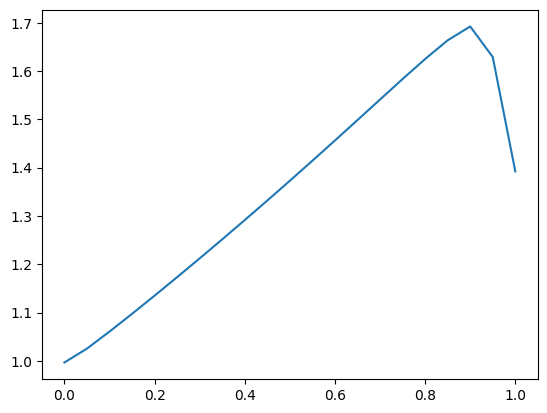

In [23]:
plt.plot(e_amp_loaded, mag_loaded[0,:,140])
# plt.plot(e_amp_loaded, phase_loaded[0,:,300])

np.float64(1.9634954084936207)

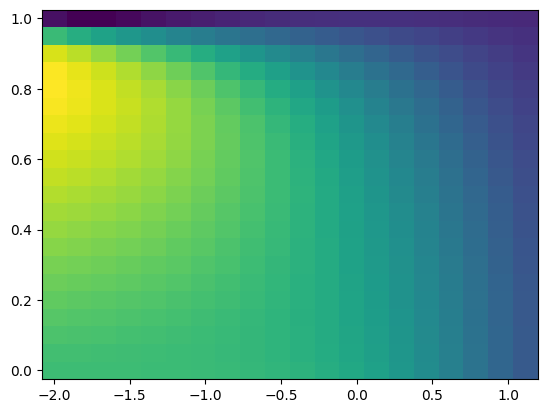

In [39]:
plt.pcolormesh(np.log10(dp_amp_loaded), e_amp_loaded, mag_loaded[:,:,160].T)
psi_r_loaded[160]

Text(0, 0.5, 'magnitude')

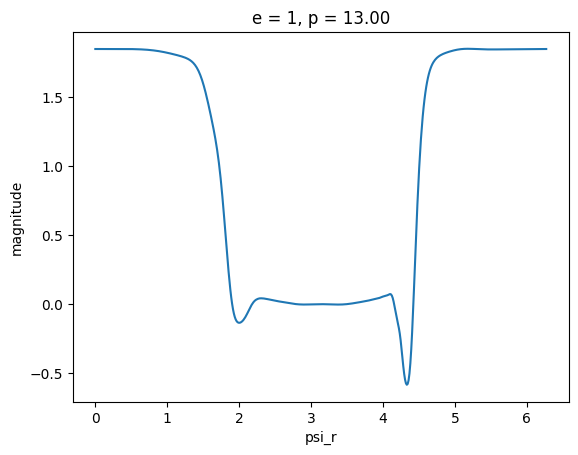

In [62]:
plt.plot(psi_r_loaded, mag_loaded[3,-1,:])
plt.title(f"e = 1, p = {dp_amp_loaded[-1]:.2f}")
plt.xlabel("psi_r")
plt.ylabel("magnitude")

Text(0, 0.5, 'phase')

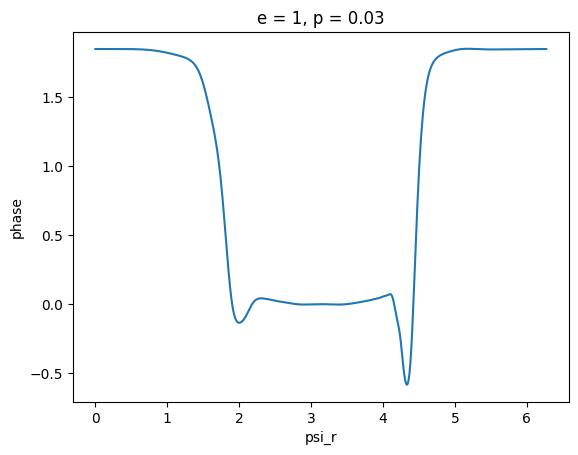

In [94]:
# plt.plot(psi_r_loaded, (mag_loaded * np.cos(phase_loaded))[3,-1,:])
# plt.title(f"e = 1, p = {dp_amp_loaded[-1]:.2f}")
# plt.xlabel("psi_r")
# plt.ylabel("magnitude")

tmp = mag_loaded * np.cos(phase_loaded) + 1j * mag_loaded * np.sin(phase_loaded)

new_mag_loaded = np.sqrt(tmp.real**2 + tmp.imag**2)
new_phase_loaded = - np.unwrap(np.arctan2(tmp.imag, tmp.real), axis=-1)

plt.plot(psi_r_loaded, mag_loaded[3,-1,:])
# plt.plot(psi_r_loaded, new_phase_loaded[3,-1,:])
# plt.plot(psi_r_loaded, (mag_loaded * np.cos(phase_loaded))[10,-1,:])
plt.title(f"e = 1, p = {dp_amp_loaded[3]:.2f}")
plt.xlabel("psi_r")
plt.ylabel("phase")

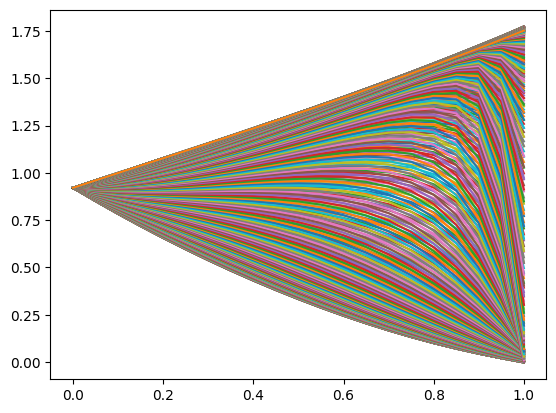

In [ ]:
plt.plot(e_amp_loaded, mag_loaded[10,:,:])

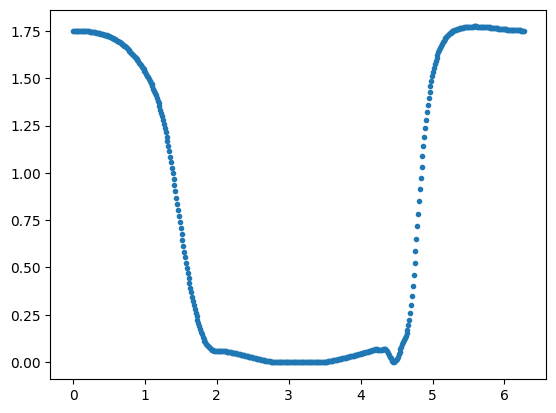

In [ ]:
plt.plot(psi_r_loaded, mag_loaded[10,-1,:], '.')